In [12]:
import warnings
import os
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, RBF
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.preprocessing import StandardScaler

from Flame_fun import FL_fun, process_flame_dataset

In [2]:
# Import des données tabulaires + nettoyage des variables d'entrée

csv_path = "Data4ML.csv"
df = pd.read_csv(csv_path, sep=";") 
base_image_folder = r".\data"

# On ne garde ici que les variables physiques d'entrée
X_df = df.iloc[:,:22] 

# Transformation de PhiInt pour travailler avec une variable bornée / plus stable
X_df.PhiInt = X_df.PhiInt / (1 + X_df.PhiInt)

# Suppression des variables quasi constantes
stds = X_df.std()
variables_cst = stds[stds < 1e-5].index.tolist()
X_df = X_df.drop(columns=variables_cst)

# Suppression des variables quasi constantes
variables_corr = ['Xst', 'Zst', 'rho1', 'MW1', 'm1', 'm2']
X_df = X_df.drop(columns=variables_corr)

# Chargement du dataset image déjà prétraité
imgs, mean_flame_image, FL_list = process_flame_dataset(csv_path,base_image_folder,1) 
FL_array = np.array(FL_list).reshape(-1,1)
X = X_df.values
n_features = X.shape[1]

# Normalisation globale des entrées physiques
scaler_X_global = StandardScaler()
X_scaled = scaler_X_global.fit_transform(X) 

In [3]:
# POD globale : extraction des coefficients modaux de référence

n_modes = 20
# On projette les images sur les n_modes premiers modes POD
svd_global = TruncatedSVD(n_components=n_modes, algorithm="randomized", random_state=42)
alphas = svd_global.fit_transform(imgs)
Vt_global = svd_global.components_

In [4]:
# GridSearch : choix du meilleur GPR pour chaque coefficient modal

warnings.filterwarnings("ignore")

iso_length = 1.0 # GPR isotrope
ard_length = np.ones(n_features) # GPR anisotrope 

param_grid_global = {
    "kernel": [
        # --- GPR isotropre 
        C(1.0) * Matern(length_scale=iso_length, nu=1.5), # Matern 1.5 : Souple
        C(1.0) * Matern(length_scale=iso_length, nu=2.5), # Matern 2.5 : Intermédiaire 
        C(1.0) * RBF(length_scale=iso_length), # RBF : Très lisse 
        # --- GPR anisotropique 
        C(1.0) * Matern(length_scale=ard_length, nu=1.5),
        C(1.0) * Matern(length_scale=ard_length, nu=2.5),
        C(1.0) * RBF(length_scale=ard_length),
    ],
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2] 
}

gpr = GaussianProcessRegressor(n_restarts_optimizer=5, normalize_y=True)
grid_search_global = GridSearchCV(estimator=gpr, 
                                  param_grid=param_grid_global, 
                                  cv=5, 
                                  scoring='neg_root_mean_squared_error', 
                                  n_jobs=-1, 
                                  verbose=0)

In [5]:
best_models = []

# On construit un modèle GPR indépendant pour chaque mode POD
# → chaque alpha_k est une variable cible différente à prédire
for k in range(n_modes):
    print(f"\n=========================================")
    print(f"MODE PLS {k+1} / {n_modes}")
    print(f"=========================================")
    
    # Cible = coefficient du mode k pour toutes les images
    # → projection des images sur le mode POD k
    alpha_k = alphas[:,k]
    
    # GridSearch :
    # on cherche les meilleurs hyperparamètres du GPR pour approximer
    # la relation : X (physique) → alpha_k (projection image)
    grid_search_global.fit(X_scaled,alpha_k)
    
    # Récupération des résultats complets de la validation croisée
    results_k = pd.DataFrame(grid_search_global.cv_results_)
    
    # On garde uniquement le meilleur modèle (score CV maximal)
    top_results = results_k.sort_values(by='mean_test_score', ascending=False).head(1)
    
    # Stockage du meilleur modèle pour ce mode
    # → sera réutilisé plus tard pour prédire sur les splits
    best_models.append(grid_search_global.best_estimator_)
    
    # Affichage des performances de chaque GPR
    for i, (index, row) in enumerate(top_results.iterrows()):
        kernel_str = str(row['param_kernel']).replace('\n', '')
        alpha_val = row['param_alpha']
        r2_mean = row['mean_test_score']
        r2_std = row['std_test_score']
        
        k_type = "ARD (Multiple)" if "length_scale=[1" in kernel_str else "Isotrope (Unique)"
        k_base = "Matern 1.5" if "nu=1.5" in kernel_str else "Matern 2.5" if "nu=2.5" in kernel_str else "RBF"
            
        print(f"Rang {i+1} : RMSE CV = {r2_mean:.3f} (±{r2_std:.3f})")
        print(f"  -> Type  : {k_base} | {k_type}")
        print(f"  -> Alpha : {alpha_val}")



MODE PLS 1 / 20
Rang 1 : RMSE CV = -6294.748 (±881.737)
  -> Type  : RBF | ARD (Multiple)
  -> Alpha : 0.01

MODE PLS 2 / 20
Rang 1 : RMSE CV = -4889.240 (±2104.108)
  -> Type  : Matern 1.5 | ARD (Multiple)
  -> Alpha : 0.01

MODE PLS 3 / 20
Rang 1 : RMSE CV = -4820.162 (±932.852)
  -> Type  : Matern 2.5 | ARD (Multiple)
  -> Alpha : 0.001

MODE PLS 4 / 20
Rang 1 : RMSE CV = -4781.426 (±1855.588)
  -> Type  : Matern 1.5 | ARD (Multiple)
  -> Alpha : 0.001

MODE PLS 5 / 20
Rang 1 : RMSE CV = -4114.705 (±1339.840)
  -> Type  : Matern 1.5 | ARD (Multiple)
  -> Alpha : 1e-05

MODE PLS 6 / 20
Rang 1 : RMSE CV = -3746.589 (±999.495)
  -> Type  : Matern 1.5 | ARD (Multiple)
  -> Alpha : 1e-05

MODE PLS 7 / 20
Rang 1 : RMSE CV = -2605.706 (±837.517)
  -> Type  : Matern 1.5 | ARD (Multiple)
  -> Alpha : 0.0001

MODE PLS 8 / 20
Rang 1 : RMSE CV = -2953.703 (±651.862)
  -> Type  : Matern 1.5 | ARD (Multiple)
  -> Alpha : 0.001

MODE PLS 9 / 20
Rang 1 : RMSE CV = -2630.185 (±946.849)
  -> Type  :

In [ ]:
# Évaluation robuste par ShuffleSplit
# À chaque split :
# 1. on refait la POD sur le train uniquement
# 2. on apprend un GPR par coefficient modal
# 3. on reconstruit les images test
# 4. on calcule la longueur de flamme sur les reconstructions

ss = ShuffleSplit(n_splits=40, test_size=0.10, random_state=42)
n_modes = 20 

FL_test = []
FL_pred = []
err_abs = []

count = 1

for train_idx, test_idx in ss.split(X): 
    print(f"Testing split {count} / 40 ...")
        
    X_tr, X_te = X[train_idx], X[test_idx]
    imgs_tr, imgs_te = imgs[train_idx], imgs[test_idx]
    FL_tr, FL_te = FL_array[train_idx], FL_array[test_idx]
    
    # Scaling des entrées physiques sur le train uniquement
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    
    # On calcule la SVD sur n_modes
    svd = TruncatedSVD(n_components=n_modes, algorithm='randomized', random_state=42)
    alphas_tr = svd.fit_transform(imgs_tr)
    Vt = svd.components_ 
    
    # Prédiction des coefficients POD sur le test
    n_test_samples = len(test_idx)
    y_pred_alphas = np.zeros((n_test_samples, n_modes))
    
    for k in range(n_modes):      
        model_k = clone(best_models[k]) # Récupération des meilleurs hyperparamètres trouvé précédement 
        model_k.fit(X_tr_s, alphas_tr[:, k]) # Entrainement de ce model sur les données train
        y_pred_alphas[:,k] = model_k.predict(X_te_s) # Prédiction des coeffs alphas
        
    # Reconstruction des images test dans l'espace image centré
    img_preds = (y_pred_alphas @ Vt) 
    
    # Mesure finale de la longueur de flamme 
    FL_pred_ss = []
    for img in img_preds:
        img_2D = img.reshape(mean_flame_image.shape) + mean_flame_image
        img_2D_clipped = np.clip(img_2D, 0, 255)
        img_8bit = img_2D_clipped.astype(np.uint8)
        longueur_calculee = FL_fun(img_8bit)
        FL_pred_ss.append(longueur_calculee)
        
    FL_pred_ss = np.array(FL_pred_ss)
    FL_test_ss = FL_te.ravel()
    
    # Stockage des résultats
    FL_test.extend(FL_test_ss)
    FL_pred.extend(FL_pred_ss)
    err_abs.extend(np.abs(FL_test_ss - FL_pred_ss))

    count += 1

# RÉSULTATS FINAUX

FL_test = np.array(FL_test)
FL_pred = np.array(FL_pred)
err_abs = np.array(err_abs)

print("\n" + "="*40)
print("-------- Results (POD + Flame_Pred) --------")
print(f"R² = {r2_score(FL_test, FL_pred):.4f}")
print(f"RMSE = {root_mean_squared_error(FL_test, FL_pred):.4f} mm")
print(f"Erreur absolue moyenne = {np.mean(err_abs/FL_test)*100:.2f} %")
print("="*40)

Testing split 1 / 40 ...
Testing split 2 / 40 ...
Testing split 3 / 40 ...
Testing split 4 / 40 ...
Testing split 5 / 40 ...
Testing split 6 / 40 ...
Testing split 7 / 40 ...
Testing split 8 / 40 ...
Testing split 9 / 40 ...
Testing split 10 / 40 ...
Testing split 11 / 40 ...
Testing split 12 / 40 ...
Testing split 13 / 40 ...
Testing split 14 / 40 ...
Testing split 15 / 40 ...
Testing split 16 / 40 ...
Testing split 17 / 40 ...
Testing split 18 / 40 ...
Testing split 19 / 40 ...
Testing split 20 / 40 ...
Testing split 21 / 40 ...
Testing split 22 / 40 ...
Testing split 23 / 40 ...
Testing split 24 / 40 ...
Testing split 25 / 40 ...
Testing split 26 / 40 ...
Testing split 27 / 40 ...
Testing split 28 / 40 ...
Testing split 29 / 40 ...
Testing split 30 / 40 ...
Testing split 31 / 40 ...
Testing split 32 / 40 ...
Testing split 33 / 40 ...
Testing split 34 / 40 ...
Testing split 35 / 40 ...
Testing split 36 / 40 ...
Testing split 37 / 40 ...
Testing split 38 / 40 ...
Testing split 39 / 40

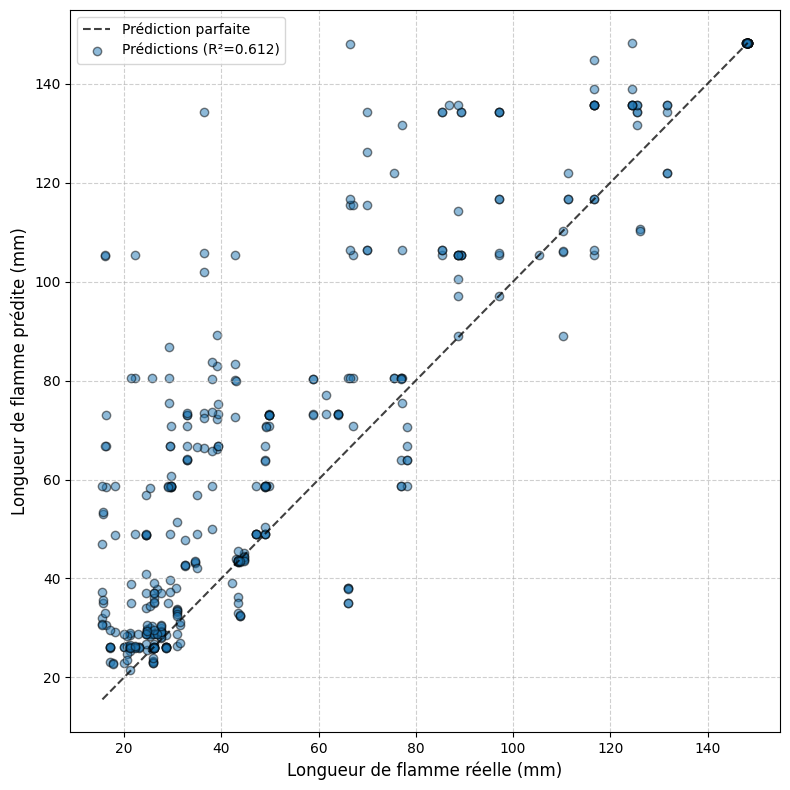

In [13]:
plt.figure(figsize=(8, 8))
# Diagonale (Référence)
lims = [np.min([FL_test.min(), FL_pred.min()]), np.max([FL_test.max(), FL_pred.max()])]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=3, label="Prédiction parfaite")

# Points de mesure (un point par image testée sur les 40 splits)
plt.scatter(FL_test, FL_pred, alpha=0.5, c='tab:blue', edgecolors='k', label=f'Prédictions (R²={r2_score(FL_test, FL_pred):.3f})')

plt.xlabel('Longueur de flamme réelle (mm)', fontsize=12)
plt.ylabel('Longueur de flamme prédite (mm)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()